In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
aapl = pd.read_csv("AAPL.csv")
aapl.head()

,Date,Close/Last,Volume,Open,High,Low
0,04/02/2025,$223.89,35905900,$221.315,$225.19,$221.02
1,04/01/2025,$223.19,36412740,$219.805,$223.68,$218.90
2,03/31/2025,$222.13,65299320,$217.005,$225.62,$216.23
3,03/28/2025,$217.90,39818620,$221.67,$223.81,$217.68
4,03/27/2025,$223.85,37094770,$221.39,$224.99,$220.5601


In [3]:
aapl.columns = ["Date", "Close/Last", "Volume", "Open", "High", "Low"]
price_cols = ["Close/Last", "Open", "High", "Low"]
for col in price_cols:
    aapl[col] = aapl[col].replace('[\$,]', '', regex=True).astype(float)

In [4]:
aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl = aapl.sort_values('Date').reset_index(drop=True)
aapl.head()

,Date,Close/Last,Volume,Open,High,Low
0,2020-04-03,60.3525,129880080,60.700,61.4250,59.7435
1,2020-04-06,65.6175,201820280,62.725,65.7775,62.3450
2,2020-04-07,64.8575,202887320,67.700,67.9250,64.7500
3,2020-04-08,66.5175,168895280,65.685,66.8425,65.3075
4,2020-04-09,66.9975,162116480,67.175,67.5175,66.1750


In [5]:
print("Date Range:", aapl['Date'].min(), "to", aapl['Date'].max())
print("Total Trading Days:", len(aapl))
print("Close Price Range: $", aapl['Close/Last'].min(), "to $", aapl['Close/Last'].max())
print("Volume Range:", aapl['Volume'].min(), "to", aapl['Volume'].max())

aapl['Return'] = aapl['Close/Last'].pct_change()
print("Average Daily Volatility (Return std):", aapl['Return'].std())

Date Range: 2020-04-03 00:00:00 to 2025-04-02 00:00:00
Total Trading Days: 1256
Close Price Range: $ 60.3525 to $ 259.02
Volume Range: 23234710 to 374295480
Average Daily Volatility (Return std): 0.01809322183186332


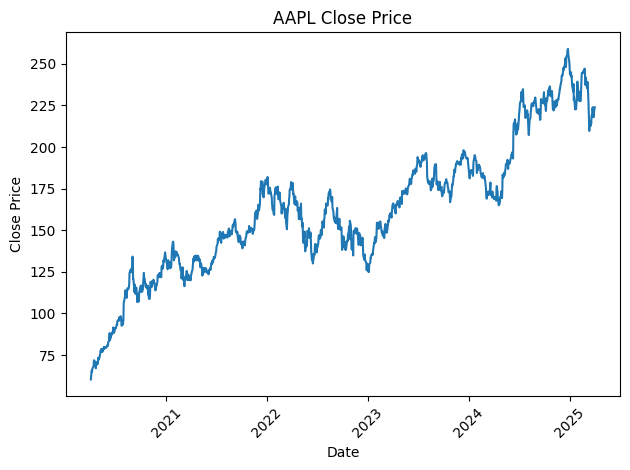

In [6]:
aapl['day_of_month'] = aapl['Date'].dt.day / 31
aapl['month'] = aapl['Date'].dt.month / 12
aapl['weekday'] = aapl['Date'].dt.weekday / 6

import matplotlib.pyplot as plt
plt.plot(aapl['Date'], aapl['Close/Last'])
plt.title("AAPL Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Simple Moving Average (SMA)

In [7]:
aapl['SMA10'] = aapl['Close/Last'].rolling(window=10).mean().shift(1)

sma_aapl_eval = aapl.dropna(subset=['SMA10', 'Close/Last'])

sma_mae = mean_absolute_error(sma_aapl_eval['Close/Last'], sma_aapl_eval['SMA10'])
sma_mse = mean_squared_error(sma_aapl_eval['Close/Last'], sma_aapl_eval['SMA10'])
sma_rmse = sma_mse ** 0.5

print("SMA10 MAE:", sma_mae)
print("SMA10 RMSE:", sma_rmse)

sma_actual_diff = sma_aapl_eval['Close/Last'].diff().fillna(0)
sma_pred_diff = sma_aapl_eval['SMA10'].diff().fillna(0)
sma_directional_match = (np.sign(sma_actual_diff) == np.sign(sma_pred_diff)).astype(int)
sma_directional_accuracy = sma_directional_match.sum() / len(sma_directional_match)
print("SMA10 Directional Accuracy:", sma_directional_accuracy)

SMA10 MAE: 4.341093699839487
SMA10 RMSE: 5.454213498028166
SMA10 Directional Accuracy: 0.5168539325842697


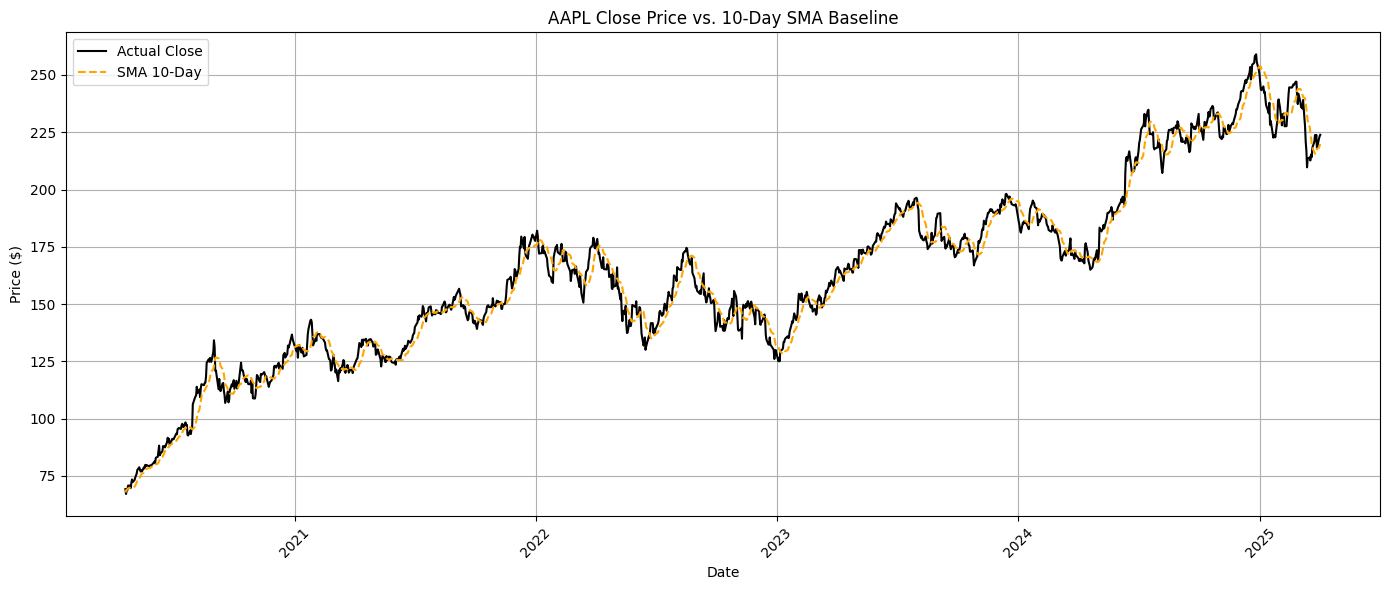

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(sma_aapl_eval['Date'], sma_aapl_eval['Close/Last'], label='Actual Close', color='black')
plt.plot(sma_aapl_eval['Date'], sma_aapl_eval['SMA10'], label='SMA 10-Day', color='orange', linestyle='--')

plt.title('AAPL Close Price vs. 10-Day SMA Baseline')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Multilayer Perceptron (MLP)

In [9]:
X = aapl[['Open', 'High', 'Low', 'Close/Last']].shift(1).dropna().values
y = aapl['Close/Last'].shift(-1).dropna().values.reshape(-1, 1)  # Next day's Close

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y).flatten()

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, shuffle=False)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [10]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.hidden_layer1 = nn.Linear(4, 64)  # Input features: 4 (OHLC)
        self.hidden_layer2 = nn.Linear(64, 32) 
        self.output_layer = nn.Linear(32, 1)  # Output: 1 (next day's Close)

    def forward(self, x):
        x = torch.relu(self.hidden_layer1(x))  # Apply ReLU activation
        x = torch.relu(self.hidden_layer2(x))
        x = self.output_layer(x)
        return x

model = MLP()

In [11]:
criterion = nn.MSELoss()  # Mean Squared Error Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
epochs = 100
for epoch in range(epochs):
    model.train()
    
    # Forward pass
    y_pred = model(X_train_tensor)
    
    # Compute loss
    loss = criterion(y_pred, y_train_tensor)
    
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.5518
Epoch [20/100], Loss: 0.2641
Epoch [30/100], Loss: 0.0724
Epoch [40/100], Loss: 0.0136
Epoch [50/100], Loss: 0.0168
Epoch [60/100], Loss: 0.0090
Epoch [70/100], Loss: 0.0081
Epoch [80/100], Loss: 0.0060
Epoch [90/100], Loss: 0.0055
Epoch [100/100], Loss: 0.0052


In [12]:
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test_tensor)

y_test_pred_np = y_scaler.inverse_transform(y_test_pred.numpy())
y_test_true_np = y_scaler.inverse_transform(y_test_tensor.numpy())

mlp_mae = mean_absolute_error(y_test_true_np, y_test_pred_np)
mlp_mse = mean_squared_error(y_test_true_np, y_test_pred_np)
mlp_rmse = mlp_mse ** 0.5

print("MLP MAE:", mlp_mae)
print("MLP RMSE:", mlp_rmse)

# Directional Accuracy
mlp_actual_np = y_test_tensor.numpy().flatten()
mlp_pred_np = y_test_pred.numpy().flatten()
mlp_actual_diff = np.diff(mlp_actual_np)
mlp_pred_diff = np.diff(mlp_pred_np)

mlp_directional_match = (np.sign(mlp_actual_diff) == np.sign(mlp_pred_diff)).astype(int)
mlp_directional_accuracy = mlp_directional_match.sum() / len(mlp_directional_match)

print("MLP Directional Accuracy:", mlp_directional_accuracy)

MLP MAE: 9.880172729492188
MLP RMSE: 11.329611297969844
MLP Directional Accuracy: 0.544


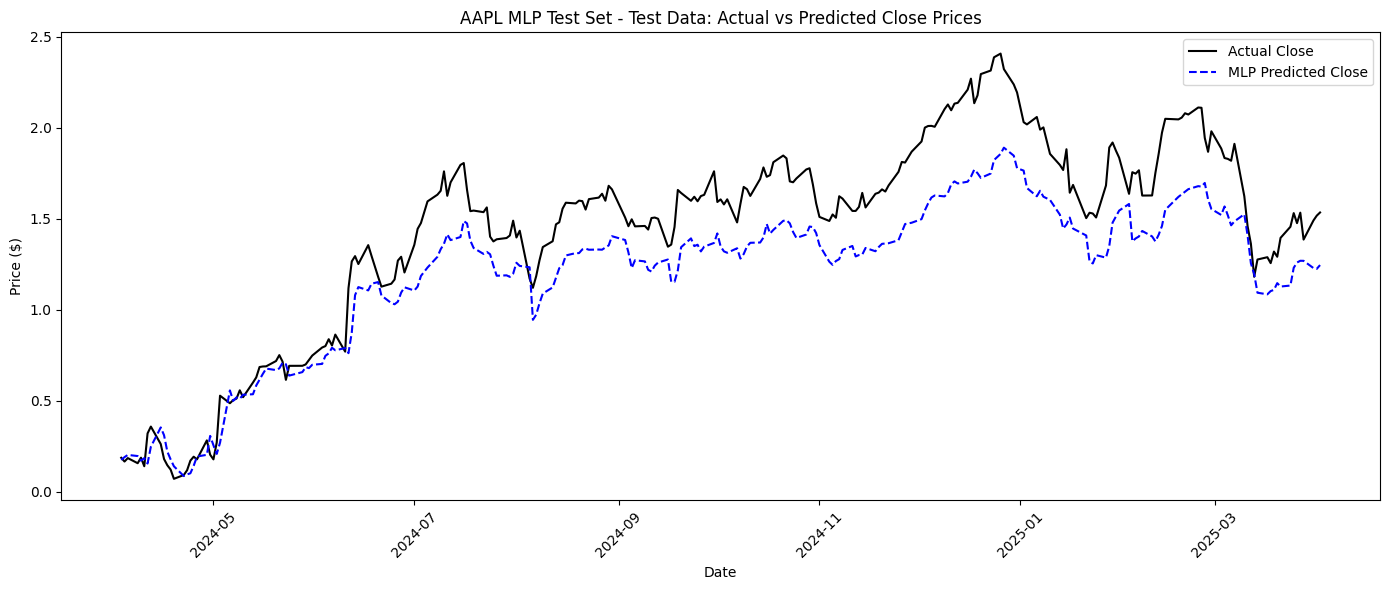

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(aapl['Date'][len(aapl) - len(y_test):], y_test_tensor.numpy(), label='Actual Close', color='black')
plt.plot(aapl['Date'][len(aapl) - len(y_test):], y_test_pred.numpy(), label='MLP Predicted Close', color='blue', linestyle='--')

plt.title('AAPL MLP Test Set - Test Data: Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

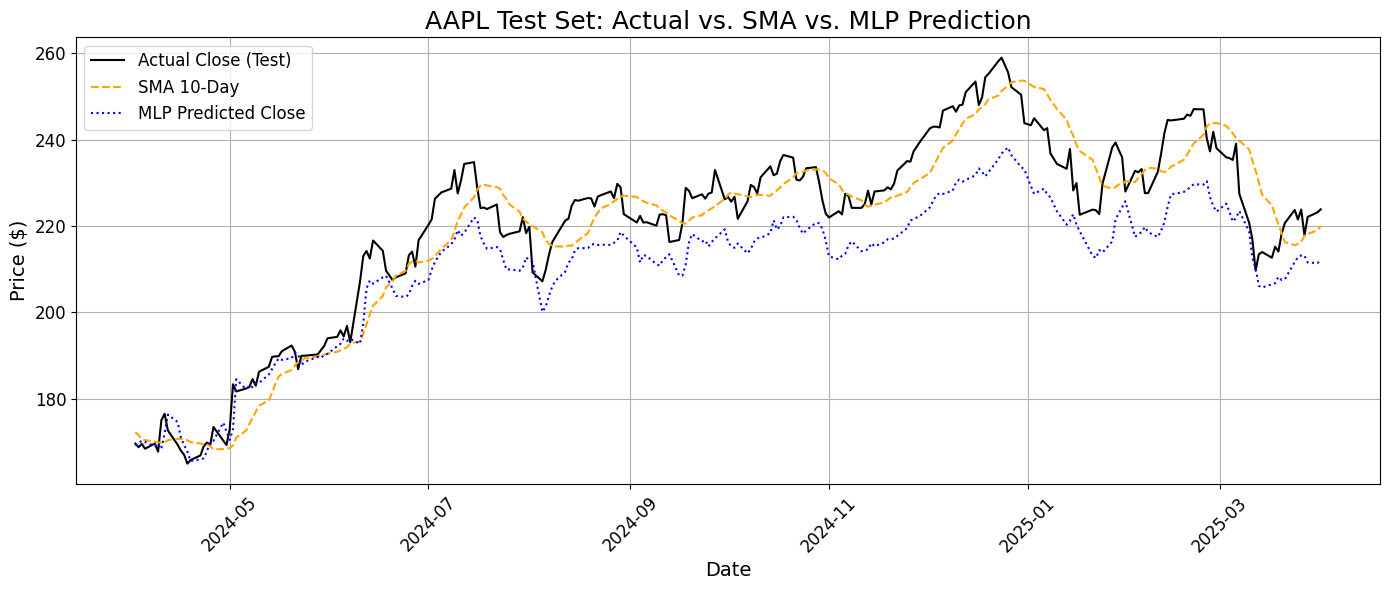

In [14]:
date_index_valid = aapl['Date'].iloc[1:-1].reset_index(drop=True)

test_dates = date_index_valid[-len(y_test):]
sma_test = sma_aapl_eval['SMA10'].iloc[-len(test_dates):].reset_index(drop=True)



plt.figure(figsize=(14, 6))

plt.plot(test_dates, y_test_true_np, label='Actual Close (Test)', color='black')

# Plot SMA baseline (aligned with test period)
plt.plot(test_dates, sma_test, label='SMA 10-Day', color='orange', linestyle='--')

# Plot MLP predictions
plt.plot(test_dates, y_test_pred_np, label='MLP Predicted Close', color='blue', linestyle='dotted')

# Plot formatting with larger fonts
plt.title('AAPL Test Set: Actual vs. SMA vs. MLP Prediction', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

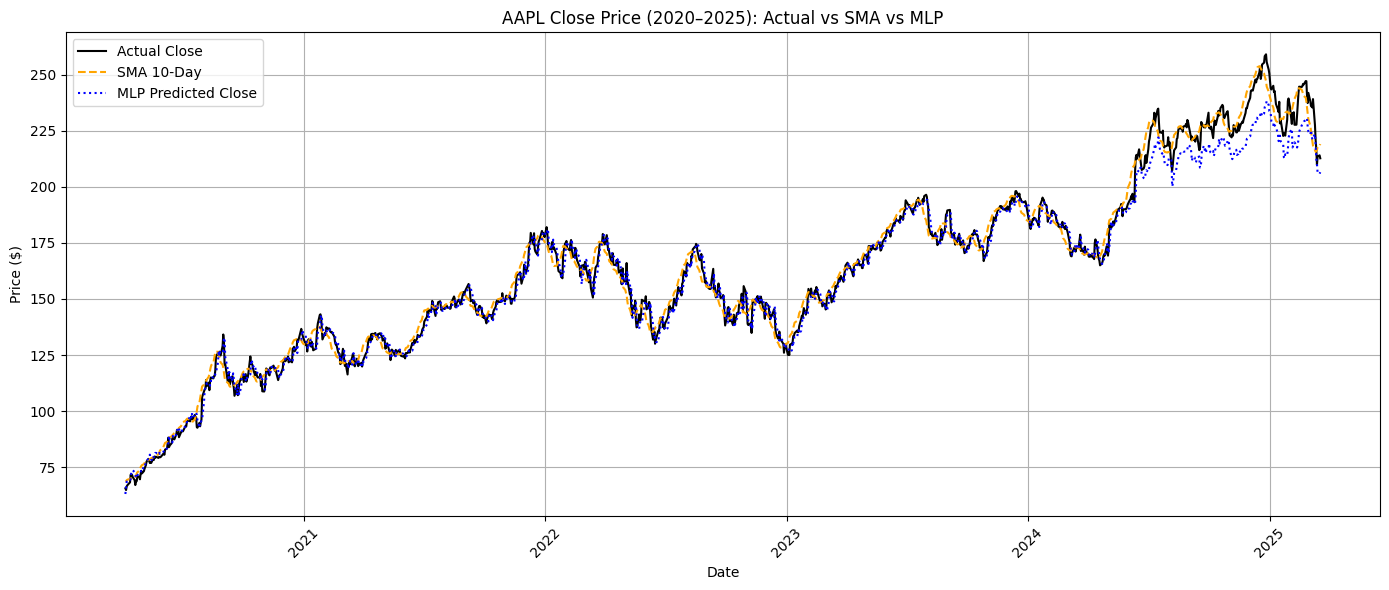

In [15]:
plt.figure(figsize=(14, 6))

date_index_full = aapl['Date'].iloc[1:-1].reset_index(drop=True)
sma_valid = sma_aapl_eval['SMA10'].reset_index(drop=True).iloc[1:-1].to_numpy()
sma_valid = sma_valid[-len(date_index_full):]  


X_full_tensor = torch.tensor(X_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    y_full_pred = model(X_full_tensor)
    
y_full_pred_np = y_scaler.inverse_transform(y_full_pred.numpy())
y_full_true_np = y_scaler.inverse_transform(y_scaled.reshape(-1, 1))


min_len = min(len(date_index_full), len(y_full_true_np), len(y_full_pred_np), len(sma_valid))
date_index_full = date_index_full[:min_len]
y_full_true_np = y_full_true_np[:min_len]
y_full_pred_np = y_full_pred_np[:min_len]
sma_valid = sma_valid[:min_len]

plt.plot(date_index_full, y_full_true_np, label='Actual Close', color='black')
plt.plot(date_index_full, sma_valid, label='SMA 10-Day', color='orange', linestyle='--')
plt.plot(date_index_full, y_full_pred_np, label='MLP Predicted Close', color='blue', linestyle='dotted')

plt.title('AAPL Close Price (2020–2025): Actual vs SMA vs MLP')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

